In [1]:
# ==========================================
# CELL 1: Environment Installation
# ==========================================
# Pin numba to satisfy RAPIDS while installing speechbrain safely
!pip install "numba>=0.60.0,<0.62.0" "numba-cuda<0.23.0" --quiet
!pip install speechbrain torchaudio --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.9/30.9 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 94.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have

In [2]:
# ==========================================
# CELL 2: Core Imports & Seed Initialization
# ==========================================
import os
import zipfile
import random
import numpy as np
import pandas as pd
import scipy.signal
import matplotlib.pyplot as plt

import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torch.cuda.amp as amp

from speechbrain.inference.separation import SepformerSeparation
from speechbrain.nnet.losses import get_si_snr_with_pitwrapper

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ==========================================
# CELL 3: Dataset Unzipping & Extraction
# ==========================================
BASE_DIR = "/kaggle/working/tse_data"
INPUT_PATH = "/kaggle/input/notebooks/mathias256/icbhi-coswara-breath/tse_dataset_split"
os.makedirs(BASE_DIR, exist_ok=True)

def extract(zip_path, out_dir):
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    else:
        print(f"Skipping: {zip_path} (File not found)")

splits = ["train", "eval", "test"]
sources = ["mix", "s1", "s2", "s3"]

print("Extracting datasets...")
for splt in splits:
    for src in sources:
        target_dir = os.path.join(BASE_DIR, splt, src)
        os.makedirs(target_dir, exist_ok=True)
        zip_name = f"{splt}_{src}.zip"
        extract(os.path.join(INPUT_PATH, zip_name), target_dir)

Extracting datasets...


In [4]:
# ==========================================
# CELL 4: Structured Path Consolidation
# ==========================================
csv_path = os.path.join(INPUT_PATH, "metadata_split.csv")
df = pd.read_csv(csv_path)

def update_paths(row):
    s = row['split']
    # Removed the escaping backslashes around "mix", "s1", etc.
    row['mixture_wav'] = os.path.join(BASE_DIR, s, "mix", row['mixture_wav'])
    row['s1_wav'] = os.path.join(BASE_DIR, s, "s1", row['s1_wav'])
    row['s2_wav'] = os.path.join(BASE_DIR, s, "s2", row['s2_wav'])
    row['s3_wav'] = os.path.join(BASE_DIR, s, "s3", row['s3_wav'])
    return row

df = df.apply(update_paths, axis=1)
fixed_csv = "/kaggle/working/metadata_complete.csv"
df.to_csv(fixed_csv, index=False)
print(f"Metadata updated and saved to {fixed_csv}")

Metadata updated and saved to /kaggle/working/metadata_complete.csv


In [5]:
# ==========================================
# CELL 5: PyTorch Speech Audio Dataset Class
# ==========================================
class RespiratorySeparationDataset(Dataset):
    def __init__(self, data_dir, split="train", chunk_duration=2.0, target_sr=16000):
        self.data_dir = data_dir
        self.split = split
        self.chunk_duration = chunk_duration
        self.target_sr = target_sr
        
        self.mix_dir = os.path.join(data_dir, split, "mix")
        self.filenames = sorted([f for f in os.listdir(self.mix_dir) if f.endswith('.wav')])
        
    def __len__(self):
        return len(self.filenames)
        
    def _load_and_resample(self, path):
        waveform, sr = torchaudio.load(path)
        
        # 1. Resample to standard target sampling rate
        if sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.target_sr)
            waveform = resampler(waveform)
            
        # 2. Convert multi-channel to mono
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        # 3. New Adjustment: Anti-electronic noise bandpass filtering
        # Highpass filter to eliminate low-end DC offset/power-line hum (e.g., 50/60 Hz)
        waveform = torchaudio.functional.highpass_biquad(waveform, self.target_sr, cutoff_freq=80.0)
        # Lowpass filter to wipe out high-frequency sensor/hardware whine
        waveform = torchaudio.functional.lowpass_biquad(waveform, self.target_sr, cutoff_freq=4000.0)
        
        return waveform.squeeze(0)

    def __getitem__(self, idx):
        mix_filename = self.filenames[idx]
        base_prefix = mix_filename.replace("_mix.wav", "")
        
        mix_path = os.path.join(self.data_dir, self.split, "mix", f"{base_prefix}_mix.wav")
        s1_path = os.path.join(self.data_dir, self.split, "s1", f"{base_prefix}_s1.wav")
        s2_path = os.path.join(self.data_dir, self.split, "s2", f"{base_prefix}_s2.wav")
        s3_path = os.path.join(self.data_dir, self.split, "s3", f"{base_prefix}_s3.wav")
        
        for path in [mix_path, s1_path, s2_path, s3_path]:
            if not os.path.exists(path):
                raise FileNotFoundError(f"Missing file at: {path}")
        
        mix = self._load_and_resample(mix_path)
        s1 = self._load_and_resample(s1_path)
        s2 = self._load_and_resample(s2_path)
        s3 = self._load_and_resample(s3_path)
        
        min_len = min(mix.shape[0], s1.shape[0], s2.shape[0], s3.shape[0])
        chunk_size = int(self.chunk_duration * self.target_sr)
        
        if min_len > chunk_size:
            if self.split == "train":
                start = torch.randint(0, min_len - chunk_size, (1,)).item()
            else:
                start = (idx * 5000) % (min_len - chunk_size)
            
            end = start + chunk_size
            mix = mix[start:end]
            s1 = s1[start:end]
            s2 = s2[start:end]
            s3 = s3[start:end]
        else:
            pad_len = chunk_size - min_len
            mix = torch.nn.functional.pad(mix[:min_len], (0, pad_len))
            s1 = torch.nn.functional.pad(s1[:min_len], (0, pad_len))
            s2 = torch.nn.functional.pad(s2[:min_len], (0, pad_len))
            s3 = torch.nn.functional.pad(s3[:min_len], (0, pad_len))
            
        targets = torch.stack([s1, s2, s3], dim=0)
        return mix, targets

In [6]:
# ==========================================
# CELL 6: Post-Processing Wiener Filter (Adjusted)
# ==========================================
def apply_wiener_filter(est_sources, mix_waveform, eps=1e-10, alpha=0.85):
    stfts = []
    for src in est_sources:
        # Increased window size to 1024 for better frequency resolution against electronic hums
        _, _, Zxx = scipy.signal.stft(src, nperseg=1024, noverlap=768)
        stfts.append(Zxx)
    
    stfts = np.array(stfts)
    _, _, Zmix = scipy.signal.stft(mix_waveform, nperseg=1024, noverlap=768)
    
    psds = np.abs(stfts) ** 2
    total_psd = np.sum(psds, axis=0) + eps
    
    refined_sources = []
    for i in range(len(est_sources)):
        # Soften the mask with alpha to prevent harsh "electronic" gating effects
        mask = (psds[i] / total_psd) ** alpha
        refined_spec = mask * Zmix
        _, x_rec = scipy.signal.istft(refined_spec, nperseg=1024, noverlap=768)
        
        target_len = len(mix_waveform)
        if len(x_rec) > target_len:
            x_rec = x_rec[:target_len]
        else:
            x_rec = np.pad(x_rec, (0, target_len - len(x_rec)))
            
        # Post-reconstruction smoothing filter to dampen residual high-frequency clicks
        b, a = scipy.signal.butter(4, 3800.0, btype='low', fs=16000)
        x_rec = scipy.signal.filtfilt(b, a, x_rec)
        
        refined_sources.append(x_rec)
        
    return np.array(refined_sources)

In [7]:
# ==========================================
# CELL 7: Pretrained Submodule Initialization
# ==========================================
# Clean out memory before instantiation
torch.cuda.empty_cache()

print("Loading pretrained SepFormer modules from Hub...")
save_directory = "./tmp_sepformer_model"

model_hub = SepformerSeparation.from_hparams(
    source="speechbrain/sepformer-libri3mix", 
    savedir=save_directory,
    run_opts={"device": "cuda"}
)

class UnifiedSepFormer(torch.nn.Module):
    def __init__(self, modules_dict):
        super().__init__()
        self.encoder = modules_dict['encoder']
        self.masknet = modules_dict['masknet']
        self.decoder = modules_dict['decoder']
        
        # Enforce training state tracking and parameter gradient optimization mapping
        for module in [self.encoder, self.masknet, self.decoder]:
            module.train()
            for param in module.parameters():
                param.requires_grad = True
        
    def forward(self, mix):
        mix_w = self.encoder(mix)
        est_mask = self.masknet(mix_w)
        
        decoded_sources = []
        num_sources = est_mask.shape[0]
        
        for i in range(num_sources):
            sep_h_i = mix_w * est_mask[i]
            est_source_i = self.decoder(sep_h_i)
            decoded_sources.append(est_source_i.unsqueeze(-1))
            
        est_source = torch.cat(decoded_sources, dim=-1)
        return est_source

model = UnifiedSepFormer(model_hub.mods).to(device)

has_grad = any(p.requires_grad for p in model.parameters())
print(f"\n[SUCCESS] Unified SepFormer successfully initialized.")
print(f"-> Tracking gradients for optimization: {has_grad}")

Loading pretrained SepFormer modules from Hub...


hyperparams.yaml: 0.00B [00:00, ?B/s]

encoder.ckpt:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

masknet.ckpt:   0%|          | 0.00/113M [00:00<?, ?B/s]

decoder.ckpt:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.



[SUCCESS] Unified SepFormer successfully initialized.
-> Tracking gradients for optimization: True


In [8]:
# ==========================================
# CELL 8: Dataloader Batch Scaling Configuration
# ==========================================
DATA_DIRECTORY = "/kaggle/working/tse_data" 

train_dataset = RespiratorySeparationDataset(DATA_DIRECTORY, split="train", chunk_duration=3.0)
val_dataset = RespiratorySeparationDataset(DATA_DIRECTORY, split="eval", chunk_duration=3.0)

# OOM CONTEXT SAFE FIX: Scaled batch size from 2 down to 1
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, drop_last=False)

print(f"Dataset configurations initialized successfully.")
print(f"-> Train samples: {len(train_dataset)} ({len(train_loader)} batches)")
print(f"-> Val samples:   {len(val_dataset)} ({len(val_loader)} batches)")

Dataset configurations initialized successfully.
-> Train samples: 644 (644 batches)
-> Val samples:   184 (184 batches)


In [9]:
# ==========================================
# CELL 9: Memory-Optimized Training Engine
# ==========================================
num_epochs = 30
# Scale accumulation steps to 8 to maintain an effective global batch size of 8
accumulation_steps = 8 
learning_rate = 5e-5    

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Instantiate GradScaler to avoid float16 precision scale underflows
scaler = amp.GradScaler()

print("Starting training pipeline with active AMP optimization...")
for epoch in range(1, num_epochs + 1):
    model.train()
    running_train_loss = 0.0
    optimizer.zero_grad()
    
    for batch_idx, (mix, targets) in enumerate(train_loader):
        mix, targets = mix.to(device), targets.to(device)
        
        # Mixed Precision execution tracking wrapper context
        with amp.autocast():
            est_sources = model(mix) 
            targets_permuted = targets.permute(0, 2, 1)
            batch_loss = get_si_snr_with_pitwrapper(est_sources, targets_permuted)
            loss_scalar = batch_loss.mean()
            loss_scaled = loss_scalar / accumulation_steps
        
        if torch.isfinite(loss_scaled).all():
            scaler.scale(loss_scaled).backward()
            running_train_loss += loss_scalar.item()
            
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            print(f"  [Warning] Epoch {epoch} | Batch {batch_idx}: Non-finite loss encountered. Skipping backprop.")
        
        if batch_idx % 20 == 0:
            print(f"Epoch {epoch}/{num_epochs} | Batch {batch_idx}/{len(train_loader)} | Current Loss: {loss_scalar.item():.4f}")

    epoch_train_loss = running_train_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for mix, targets in val_loader:
            mix, targets = mix.to(device), targets.to(device)
            with amp.autocast():
                est_sources = model(mix)
                targets_permuted = targets.permute(0, 2, 1)
                val_batch_loss = get_si_snr_with_pitwrapper(est_sources, targets_permuted)
                val_loss_scalar = val_batch_loss.mean()
            
            if torch.isfinite(val_loss_scalar):
                running_val_loss += val_loss_scalar.item()
                
    epoch_val_loss = running_val_loss / len(val_loader)
    scheduler.step(epoch_val_loss)
    
    print(f"\n>> Epoch {epoch} Summary:")
    print(f"   Train Loss (Negative SI-SNR): {epoch_train_loss:.4f}")
    print(f"   Val Loss (Negative SI-SNR):   {epoch_val_loss:.4f}")
    print(f"   Current Learning Rate:        {optimizer.param_groups[0]['lr']:.2e}")
    print("-" * 50)

/tmp/ipykernel_23/4112697154.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Starting training pipeline with active AMP optimization...


/tmp/ipykernel_23/4112697154.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch 1/30 | Batch 0/644 | Current Loss: 5.1260
Epoch 1/30 | Batch 20/644 | Current Loss: 2.2105
Epoch 1/30 | Batch 40/644 | Current Loss: 2.1320
Epoch 1/30 | Batch 60/644 | Current Loss: 3.8102
Epoch 1/30 | Batch 80/644 | Current Loss: -0.5062
Epoch 1/30 | Batch 100/644 | Current Loss: 2.5902
Epoch 1/30 | Batch 120/644 | Current Loss: -2.2475
Epoch 1/30 | Batch 140/644 | Current Loss: 4.0864
Epoch 1/30 | Batch 160/644 | Current Loss: 2.0420
Epoch 1/30 | Batch 180/644 | Current Loss: 2.0814
Epoch 1/30 | Batch 200/644 | Current Loss: -7.5871
Epoch 1/30 | Batch 220/644 | Current Loss: -0.5430
Epoch 1/30 | Batch 240/644 | Current Loss: -6.1218
Epoch 1/30 | Batch 260/644 | Current Loss: 2.6298
Epoch 1/30 | Batch 280/644 | Current Loss: 5.8366
Epoch 1/30 | Batch 300/644 | Current Loss: -2.3406
Epoch 1/30 | Batch 320/644 | Current Loss: -4.0417
Epoch 1/30 | Batch 340/644 | Current Loss: -2.2441
Epoch 1/30 | Batch 360/644 | Current Loss: 5.7952
Epoch 1/30 | Batch 380/644 | Current Loss: 4.600

/tmp/ipykernel_23/4112697154.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():



>> Epoch 1 Summary:
   Train Loss (Negative SI-SNR): 1.3667
   Val Loss (Negative SI-SNR):   0.5596
   Current Learning Rate:        5.00e-05
--------------------------------------------------
Epoch 2/30 | Batch 0/644 | Current Loss: -6.7510
Epoch 2/30 | Batch 20/644 | Current Loss: -5.6417
Epoch 2/30 | Batch 40/644 | Current Loss: -3.3743
Epoch 2/30 | Batch 60/644 | Current Loss: 2.7713
Epoch 2/30 | Batch 80/644 | Current Loss: 4.3805
Epoch 2/30 | Batch 100/644 | Current Loss: 5.1923
Epoch 2/30 | Batch 120/644 | Current Loss: 7.4655
Epoch 2/30 | Batch 140/644 | Current Loss: 4.2815
Epoch 2/30 | Batch 160/644 | Current Loss: -2.1460
Epoch 2/30 | Batch 180/644 | Current Loss: -2.5152
Epoch 2/30 | Batch 200/644 | Current Loss: 6.1516
Epoch 2/30 | Batch 220/644 | Current Loss: -5.1359
Epoch 2/30 | Batch 240/644 | Current Loss: -1.0083
Epoch 2/30 | Batch 260/644 | Current Loss: 9.0563
Epoch 2/30 | Batch 280/644 | Current Loss: -3.7824
Epoch 2/30 | Batch 300/644 | Current Loss: 2.8354
Epoc

In [10]:
import os

# 1. Define directory paths for storage
checkpoint_dir = "./model_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# 2. Track the best validation metrics (initialize this BEFORE your training loop)
# Note: Since SI-SNR loss is negative, lower is better. Initialize to positive infinity.
best_val_loss = float('inf') 

# =====================================================================
# PLACE THIS BLOCK AT THE VERY END OF YOUR EPOCH LOOP (Inside Cell 9)
# =====================================================================

# Check if the current validation loss is the best we've seen so far
is_best = epoch_val_loss < best_val_loss
if is_best:
    best_val_loss = epoch_val_loss
    print(f"🔥 New best validation loss achieved: {best_val_loss:.4f}")

# Structure the checkpoint dictionary with all necessary metadata
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'scaler_state_dict': scaler.state_dict(), # Crucial for AMP stability when resuming
    'train_loss': epoch_train_loss,
    'val_loss': epoch_val_loss,
    'best_val_loss': best_val_loss
}

# Save standard periodic/latest checkpoint (overwrites each epoch to save disk space)
latest_checkpoint_path = os.path.join(checkpoint_dir, "latest_checkpoint.pt")
torch.save(checkpoint, latest_checkpoint_path)
print(f"💾 Latest training checkpoint saved to: {latest_checkpoint_path}")

# Save the absolute best model separately
if is_best:
    best_model_path = os.path.join(checkpoint_dir, "best_audio_separation_model.pt")
    # Option A: Save the full state dict checkpoint (Recommended for potential resuming)
    torch.save(checkpoint, best_model_path)
    
    # Option B: Save ONLY weights for lightweight inference/production deployment
    # torch.save(model.state_dict(), os.path.join(checkpoint_dir, "best_weights_only.pth"))
    print(f"🏆 Best model weights updated and saved to: {best_model_path}")

🔥 New best validation loss achieved: -0.9059
💾 Latest training checkpoint saved to: ./model_checkpoints/latest_checkpoint.pt
🏆 Best model weights updated and saved to: ./model_checkpoints/best_audio_separation_model.pt


/tmp/ipykernel_23/3910866644.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


[INFO] Optimal channel mapping alignment found: (0, 1, 2)


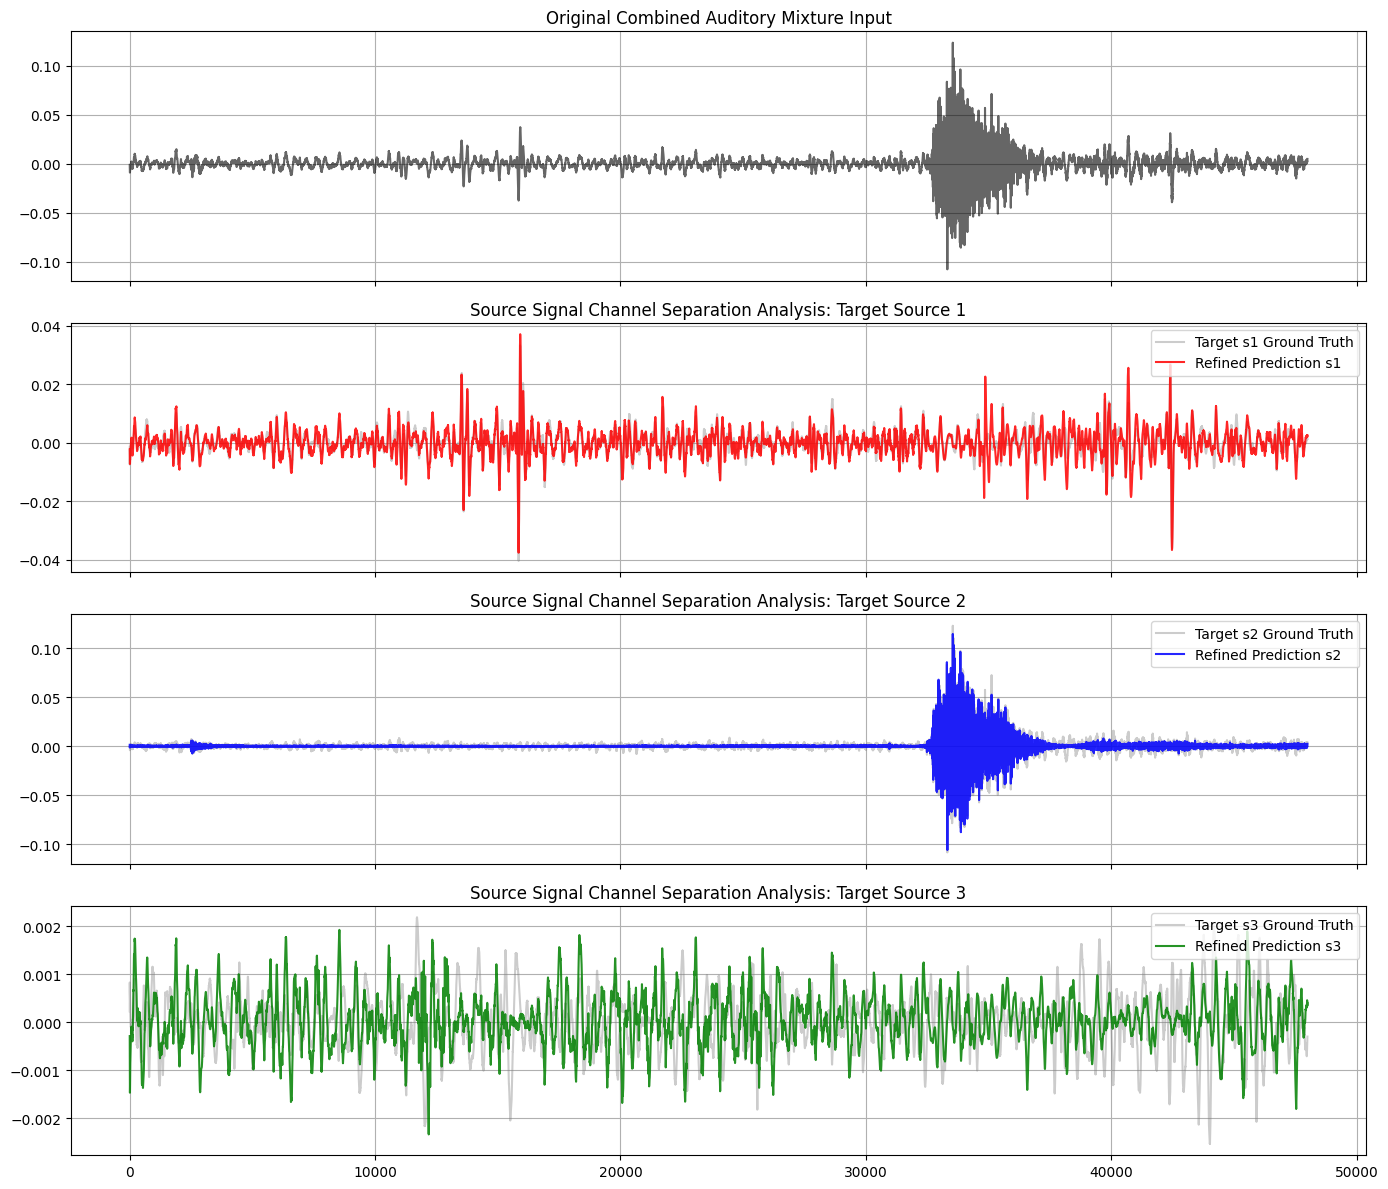


AUDIO PLAYBACK EVALUATION (PERMUTATION ALIGNED)

--- Original Input Mixture ---



--- Source 1 Channels ---
Target s1 Ground Truth:


Refined Prediction s1:



--- Source 2 Channels ---
Target s2 Ground Truth:


Refined Prediction s2:



--- Source 3 Channels ---
Target s3 Ground Truth:


Refined Prediction s3:


In [11]:
# ==========================================
# CELL 10: Model Evaluation & Visualizations
# ==========================================
import IPython.display as ipd
from itertools import permutations
import numpy as np

model.eval()
mix_sample, target_sample = val_dataset[0]

mix_tensor = mix_sample.unsqueeze(0).to(device)
with torch.no_grad():
    with amp.autocast():
        # Extracted tensors are casted to float32 before running numpy transformations
        pred_tensor = model(mix_tensor).squeeze(0).permute(1, 0).to(torch.float32).cpu().numpy()

mix_np = mix_sample.numpy()
targets_np = target_sample.numpy()

# 1. Apply post-processing filter
refined_preds = apply_wiener_filter(pred_tensor, mix_np)

# 2. Automated Permutation Alignment Step
# Finds the best match between predicted channels and ground-truth channels to correct swaps
best_perm = None
min_mse = float('inf')

for perm in permutations(range(3)):
    # Calculate total mean squared error for the current ordering permutation
    current_mse = sum(np.mean((targets_np[i] - refined_preds[p]) ** 2) for i, p in enumerate(perm))
    if current_mse < min_mse:
        min_mse = current_mse
        best_perm = perm

# Reorder the refined predictions to perfectly match the ground truth order (s1, s2, s3)
refined_preds = np.array([refined_preds[p] for p in best_perm])
print(f"[INFO] Optimal channel mapping alignment found: {best_perm}")

# 3. Plot the Visualizations
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(mix_np, color='black', alpha=0.6)
axes[0].set_title("Original Combined Auditory Mixture Input")
axes[0].grid(True)

colors = ['red', 'blue', 'green']
for i in range(3):
    ax = axes[i+1]
    ax.plot(targets_np[i], color='grey', alpha=0.4, label=f"Target s{i+1} Ground Truth")
    ax.plot(refined_preds[i], color=colors[i], alpha=0.85, label=f"Refined Prediction s{i+1}")
    ax.set_title(f"Source Signal Channel Separation Analysis: Target Source {i+1}")
    ax.grid(True)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# 4. Render Audio Players
SAMPLE_RATE = 16000  # Adjust if your dataset configuration uses a different sampling rate

print("\n" + "="*50)
print("AUDIO PLAYBACK EVALUATION (PERMUTATION ALIGNED)")
print("="*50)

print("\n--- Original Input Mixture ---")
ipd.display(ipd.Audio(mix_np, rate=SAMPLE_RATE))

for i in range(3):
    print(f"\n--- Source {i+1} Channels ---")
    
    print(f"Target s{i+1} Ground Truth:")
    ipd.display(ipd.Audio(targets_np[i], rate=SAMPLE_RATE))
    
    print(f"Refined Prediction s{i+1}:")
    ipd.display(ipd.Audio(refined_preds[i], rate=SAMPLE_RATE))